In [1]:
from langgraph.graph import StateGraph,START, END
from typing import TypedDict
from dotenv import load_dotenv
import os 
from langchain_groq import ChatGroq
from pydantic import BaseModel, Field


c:\Users\Ansh\OneDrive\Desktop\Langraph\meraenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()
llm=ChatGroq(
    model="llama-3.1-8b-instant",
    groq_api_key=os.getenv('GROQ_API_KEY'),
    temperature=0
)

In [3]:
from typing import Literal


class Sentiment_Schema(BaseModel):
    sentiment: Literal['positive','negative'] = Field(description="The sentiment of the review, either 'positive' or 'negative'")
    
structured_model = llm.with_structured_output(Sentiment_Schema)  # this is our new model that gives output according to our requirements..

In [5]:
structured_model.invoke("honda cars are very relaibale")   #only 1 thing is there in llm output no metadata and all is present

Sentiment_Schema(sentiment='positive')

In [9]:
structured_model.invoke("honda cars are very relaibale").sentiment   #only 2 tings are there in llm output no metadata and all is present

'positive'

In [8]:
class Cust(TypedDict):
    review: str
    sentiment:str
    response: str
    f1: str
    f2: str
    f3: str

In [10]:
def senti(state:Cust)->Cust:
    prompt = f"""
    Analyze the sentiment of the following review and classify it as either "positive" or "negative"
      only one word without any explanation.
      {state['review']}""" 
    sentiment= structured_model.invoke(prompt).sentiment
    return {'sentiment':sentiment}

   

In [11]:
def check_sentiment(state:Cust):   # this funciton will take  state as a input and it will return any of these one node

    if state['sentiment']=='positive':
        return 'pos_res'
    else:
        return 'run_dia'

In [12]:
def pos_res(state:Cust)->Cust:
    prompt = f"""
    Write a positive response to the following review:{state['review']}
    """
    response = llm.invoke(prompt).content  # dont take strucutre wala model becuase it will give only sentiment.
    return {'response': response}

In [13]:
def run_dia(state:Cust)->Cust:
    f1 = llm.invoke(f"What is the tone of the review: {state['review']}").content  
    f2 = llm.invoke(f"What is the urgency of the review: {state['review']}").content
    f3 = llm.invoke(f"What is the issue type of the review: {state['review']}").content
    return {'f1':f1,'f2':f2,'f3':f3}

In [14]:
def neg_res(state:Cust)->Cust:
    prompt = f"""
    Write a negative response to the following review using these details 
    {state['f1']}
    {state['f2']}
    {state['f3']}
    The review is:
    :{state['review']}
    """
    response = llm.invoke(prompt).content  # dont take strucutre wala model becuase it will give only sentiment.
    return {'response': response}

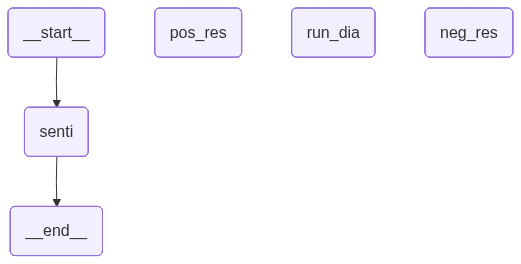

In [ ]:
graph = StateGraph(Cust)

graph.add_node('senti',senti)
graph.add_node('pos_res',pos_res)
graph.add_node('run_dia',run_dia)
graph.add_node('neg_res',neg_res)

graph.add_edge(START,'senti')
graph.add_conditional_edges('senti',check_sentiment)  # here instead of check_senti a node will be present...
graph.add_edge('run_dia','neg_res')
# graph.add_edge('pos_res',END)
# graph.add_edge('neg_res',END)

graph.compile()




In [16]:
workflow = graph.compile()
final_state = workflow.invoke({'review':"The product stopped working after a week and customer service was unhelpful."})
from pprint import pprint
pprint(final_state, width=100, depth=None, compact=False)

{'f1': 'The tone of the review is negative. The reviewer expresses dissatisfaction with the '
       "product's performance (it stopped working after a week) and the customer service they "
       'received (they found it unhelpful). This tone suggests that the reviewer is unhappy with '
       'their experience and is warning others to be cautious.',
 'f2': 'The urgency of the review is HIGH. \n'
       '\n'
       'The customer experienced a critical issue with the product (it stopped working after a '
       'week), which suggests a potential design or manufacturing flaw. Additionally, the customer '
       'service was unhelpful, which implies that the company may not be responsive to customer '
       'concerns or willing to resolve issues.\n'
       '\n'
       "Given these factors, it's essential to address the customer's concerns promptly to:\n"
       '\n'
       "1. Prevent further negative reviews and damage to the company's reputation.\n"
       '2. Show that the company va

In [17]:
final_state['response'] # to access response (a single key) from final state

"**A Response to Your Concerns**\n\nDear [Reviewer's Name],\n\nWe are truly sorry to hear that our product stopped working after just a week and that our customer service team was unable to assist you in resolving the issue. We understand the frustration and disappointment this has caused, and we want to assure you that we take these concerns very seriously.\n\nAt [Company Name], we pride ourselves on delivering high-quality products and providing exceptional customer service. It's clear that we fell short in your case, and for that, we apologize. We want to make things right and ensure that you have a positive experience with our brand.\n\nWe would like to offer you a replacement product or a full refund, whichever you prefer. We will also provide you with a prepaid return shipping label so that you can easily send back the defective product.\n\nRegarding the customer service issue, we will be conducting an internal review to identify the root cause of the problem and take corrective 